# Patrón Creacional: Builder — Historia clínica

El patrón Builder permite construir un objeto complejo **paso a paso**, separando el proceso de construcción de su representación final. Es útil cuando el objeto tiene muchas partes opcionales y armarlo todo en un único constructor lo vuelve difícil de leer y de mantener.

En una clínica, una **historia clínica** de una consulta no siempre tiene las mismas secciones: puede incluir antecedentes, diagnóstico, tratamiento, exámenes solicitados y notas de seguimiento — pero muchas consultas no usan todas. Representar esto con un solo constructor obliga a decidir de antemano un orden fijo de parámetros, muchos de ellos opcionales.

## Sin patrón Builder (forma errónea)

El cliente debe pasar todos los datos en un único constructor. Cuantas más secciones opcionales tenga la historia clínica, más parámetros opcionales se acumulan, y es fácil confundir el orden o el significado de cada `None`.

In [7]:
class HistoriaClinica:
    def __init__(self, paciente, medico, motivo_consulta,
                 antecedentes=None, diagnostico=None, tratamiento=None,
                 examenes=None, notas_seguimiento=None):
        self.paciente = paciente
        self.medico = medico
        self.motivo_consulta = motivo_consulta
        self.antecedentes = antecedentes
        self.diagnostico = diagnostico
        self.tratamiento = tratamiento
        self.examenes = examenes
        self.notas_seguimiento = notas_seguimiento

    def mostrar(self):
        print(f"Historia clínica de {self.paciente} — atendido por {self.medico}")
        print(f"  Motivo: {self.motivo_consulta}")
        if self.antecedentes:
            print(f"  Antecedentes: {self.antecedentes}")
        if self.diagnostico:
            print(f"  Diagnóstico: {self.diagnostico}")
        if self.tratamiento:
            print(f"  Tratamiento: {self.tratamiento}")
        if self.examenes:
            print(f"  Exámenes: {self.examenes}")
        if self.notas_seguimiento:
            print(f"  Notas de seguimiento: {self.notas_seguimiento}")

In [8]:
# Para una consulta simple, ya hay que pasar None explícitos para las secciones no usadas.
historia_simple = HistoriaClinica(
    paciente="Laura Gómez",
    medico="Dr. Pérez",
    motivo_consulta="Control general",
    antecedentes=None,
    diagnostico="Paciente sana",
    tratamiento=None,
    examenes=None,
    notas_seguimiento=None,
)
historia_simple.mostrar()

# Para una consulta compleja, hay que acertar el orden y significado de 8 posiciones/parámetros.
historia_compleja = HistoriaClinica(
    "Pedro Martínez", "Dra. Ríos", "Dolor torácico",
    "Hipertenso, fumador", "Posible angina", "Reposo y control de presión",
    "Electrocardiograma, perfil lipídico", "Reevaluar en 1 semana",
)
historia_compleja.mostrar()

Historia clínica de Laura Gómez — atendido por Dr. Pérez
  Motivo: Control general
  Diagnóstico: Paciente sana
Historia clínica de Pedro Martínez — atendido por Dra. Ríos
  Motivo: Dolor torácico
  Antecedentes: Hipertenso, fumador
  Diagnóstico: Posible angina
  Tratamiento: Reposo y control de presión
  Exámenes: Electrocardiograma, perfil lipídico
  Notas de seguimiento: Reevaluar en 1 semana


### Por qué esto es un problema

- Con 5 secciones opcionales, el constructor ya tiene 8 parámetros: agregar una sección nueva (por ejemplo "alergias") obliga a insertar otro parámetro y revisar todos los llamados existentes.
- En `historia_compleja`, los argumentos posicionales no dicen qué representan: es fácil intercambiar `diagnostico` con `tratamiento` por error y el código seguiría "funcionando" sin avisar.
- No hay forma de armar la historia clínica incrementalmente (por ejemplo, agregar el diagnóstico más tarde, cuando llegan los resultados de laboratorio) sin volver a construir el objeto entero.

## Con patrón Builder (forma correcta)

`HistoriaClinicaBuilder` arma la historia clínica paso a paso mediante métodos encadenables (cada uno retorna `self`); solo se llaman los métodos de las secciones que aplican. `build()` produce el objeto final.

In [9]:
class HistoriaClinicaBuilder:
    def __init__(self, paciente, medico, motivo_consulta):
        self._paciente = paciente
        self._medico = medico
        self._motivo_consulta = motivo_consulta
        self._antecedentes = None
        self._diagnostico = None
        self._tratamiento = None
        self._examenes = None
        self._notas_seguimiento = None

    def con_antecedentes(self, antecedentes):
        self._antecedentes = antecedentes
        return self

    def con_diagnostico(self, diagnostico):
        self._diagnostico = diagnostico
        return self

    def con_tratamiento(self, tratamiento):
        self._tratamiento = tratamiento
        return self

    def con_examenes(self, examenes):
        self._examenes = examenes
        return self

    def con_notas_seguimiento(self, notas):
        self._notas_seguimiento = notas
        return self

    def build(self):
        return HistoriaClinica(
            paciente=self._paciente,
            medico=self._medico,
            motivo_consulta=self._motivo_consulta,
            antecedentes=self._antecedentes,
            diagnostico=self._diagnostico,
            tratamiento=self._tratamiento,
            examenes=self._examenes,
            notas_seguimiento=self._notas_seguimiento,
        )


class DirectorHistoriaClinica:
    """Ensambla recetas comunes de historia clínica reutilizando el mismo builder."""

    def historia_control_general(self, builder):
        return builder.con_diagnostico("Paciente sano, sin hallazgos relevantes").build()

    def historia_urgencia_cardiaca(self, builder):
        return (
            builder
            .con_antecedentes("Hipertenso, fumador")
            .con_diagnostico("Posible angina")
            .con_tratamiento("Reposo y control de presión")
            .con_examenes("Electrocardiograma, perfil lipídico")
            .con_notas_seguimiento("Reevaluar en 1 semana")
            .build()
        )

In [10]:
director = DirectorHistoriaClinica()

historia_simple = director.historia_control_general(
    HistoriaClinicaBuilder(paciente="Laura Gómez", medico="Dr. Pérez", motivo_consulta="Control general")
)
historia_simple.mostrar()

print()

historia_compleja = director.historia_urgencia_cardiaca(
    HistoriaClinicaBuilder(paciente="Pedro Martínez", medico="Dra. Ríos", motivo_consulta="Dolor torácico")
)
historia_compleja.mostrar()
print()


Historia clínica de Laura Gómez — atendido por Dr. Pérez
  Motivo: Control general
  Diagnóstico: Paciente sano, sin hallazgos relevantes

Historia clínica de Pedro Martínez — atendido por Dra. Ríos
  Motivo: Dolor torácico
  Antecedentes: Hipertenso, fumador
  Diagnóstico: Posible angina
  Tratamiento: Reposo y control de presión
  Exámenes: Electrocardiograma, perfil lipídico
  Notas de seguimiento: Reevaluar en 1 semana



## UML del patrón Builder aplicado

```plantuml
@startuml
class HistoriaClinica {
    + paciente
    + medico
    + motivo_consulta
    + antecedentes
    + diagnostico
    + tratamiento
    + examenes
    + notas_seguimiento
    + mostrar()
}
class HistoriaClinicaBuilder {
    + con_antecedentes(antecedentes)
    + con_diagnostico(diagnostico)
    + con_tratamiento(tratamiento)
    + con_examenes(examenes)
    + con_notas_seguimiento(notas)
    + build()
}
class DirectorHistoriaClinica {
    + historia_control_general(builder)
    + historia_urgencia_cardiaca(builder)
}
HistoriaClinicaBuilder ..> HistoriaClinica : build() crea
DirectorHistoriaClinica --> HistoriaClinicaBuilder : usa
@enduml
```

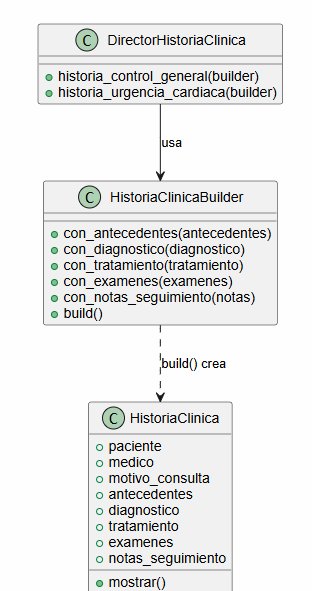

## Por qué Builder y no otro patrón

Se consideró **Factory Method**, pero ese patrón resuelve "qué clase concreta instanciar", no "cómo ensamblar un objeto con muchas partes opcionales en varios pasos". Aquí el problema no es elegir entre tipos de historia clínica, sino evitar un constructor con demasiados parámetros opcionales y permitir ensamblar la historia incrementalmente (agregar diagnóstico, luego tratamiento, luego notas, en cualquier orden). Builder encaja exactamente con ese problema: separa la construcción paso a paso de la representación final, y el `DirectorHistoriaClinica` reutiliza esos pasos para armar recetas comunes sin duplicar lógica.
